# **Patient Risk Clustering using K-Means and Gaussian Mixture Model (GMM)**
**Objective**

The objective of this notebook is to identify hidden patient groups (risk tiers) using unsupervised learning techniques.

Unlike supervised learning, clustering does not use the target variable (cardio). Instead, it groups patients based on similarities in their clinical characteristics.

The clustering results will help identify:
- Low Risk Population
- Moderate Risk Population
- High Risk Population

Algorithms Used:

- K-Means Clustering
- Gaussian Mixture Model (GMM)

Evaluation Techniques:

- Elbow Method
- Silhouette Score

Final Output:

- Population Risk Dashboard
- Cluster Profiling
- Risk Tier Analysis

# 1.Import Libraries

In [1]:
# ============================================
# 1. IMPORT LIBRARIES
# ============================================

import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


# 2. Load Dataset
**Your original dataset uses semicolon-separated values, so this version automatically detects the separator.**

In [8]:
# ============================================
# 2. LOAD DATASET
# ============================================

df = pd.read_csv("/kaggle/input/datasets/garvkorat/abdefg/cardio_train.csv",sep = ';')
print("Dataset shape:", df.shape)


Dataset shape: (70000, 13)


# 3. Understand Dataset

In [10]:
# ============================================
# 3. BASIC DATA INFORMATION
# ============================================

print("Dataset Shape")
print(df.shape)

print()

print("First Five Rows")

display(df.head())

print()

print("Columns")

print(df.columns.tolist())

Dataset Shape
(70000, 13)

First Five Rows


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0



Columns
['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']


# 4. Dataset Information

In [11]:
print("Dataset Information")

df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


# 5. Dataset Description

In [12]:
# ============================================
# 5. STATISTICAL SUMMARY
# ============================================

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
id,70000.0,49972.419900,28851.302323,0.0,25006.75,50001.5,74889.25,99999.0
age,70000.0,19468.865814,2467.251667,10798.0,17664.00,19703.0,21327.00,23713.0
gender,70000.0,1.349571,0.476838,1.0,1.00,1.0,2.00,2.0
height,70000.0,164.359229,8.210126,55.0,159.00,165.0,170.00,250.0
weight,70000.0,74.205690,14.395757,10.0,65.00,72.0,82.00,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.00,120.0,140.00,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.00,80.0,90.00,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.00,1.0,2.00,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.00,1.0,1.00,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.00,0.0,0.00,1.0


#  6. Data Cleaning
**We will remove:**
* Duplicate patients
* Invalid age
* Invalid height
* Invalid weight
* Invalid blood pressure
* Invalid cholesterol/glucose values





In [13]:
# ============================================
# 6. DATA CLEANING
# ============================================

df_clean = df.copy()

print("Original rows:", len(df_clean))

# Remove duplicates
df_clean = df_clean.drop_duplicates()

# Age: original age is in days
df_clean = df_clean[
    (df_clean["age"] >= 3650) &
    (df_clean["age"] <= 36500)
]

# Height
df_clean = df_clean[
    (df_clean["height"] >= 100) &
    (df_clean["height"] <= 250)
]

# Weight
df_clean = df_clean[
    (df_clean["weight"] >= 30) &
    (df_clean["weight"] <= 200)
]

# Systolic BP
df_clean = df_clean[
    (df_clean["ap_hi"] >= 70) &
    (df_clean["ap_hi"] <= 250)
]

# Diastolic BP
df_clean = df_clean[
    (df_clean["ap_lo"] >= 40) &
    (df_clean["ap_lo"] <= 150)
]

# Systolic should be greater than diastolic
df_clean = df_clean[
    df_clean["ap_hi"] >= df_clean["ap_lo"]
]

# Valid categorical values
df_clean = df_clean[df_clean["cholesterol"].isin([1, 2, 3])]
df_clean = df_clean[df_clean["gluc"].isin([1, 2, 3])]
df_clean = df_clean[df_clean["gender"].isin([1, 2])]
df_clean = df_clean[df_clean["smoke"].isin([0, 1])]
df_clean = df_clean[df_clean["alco"].isin([0, 1])]
df_clean = df_clean[df_clean["active"].isin([0, 1])]
df_clean = df_clean[df_clean["cardio"].isin([0, 1])]

print("Rows after cleaning:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

Original rows: 70000
Rows after cleaning: 68636
Rows removed: 1364


# 7. Feature Engineering
**This makes our clustering more meaningful.**
**We create:**
* Age in years
* BMI
* Pulse pressure
* Blood pressure ratio

In [14]:
# ============================================
# 7. FEATURE ENGINEERING
# ============================================

df_clean["age_years"] = df_clean["age"] / 365.25

df_clean["BMI"] = (
    df_clean["weight"] /
    ((df_clean["height"] / 100) ** 2)
)

df_clean["pulse_pressure"] = (
    df_clean["ap_hi"] - df_clean["ap_lo"]
)

df_clean["bp_ratio"] = (
    df_clean["ap_hi"] / df_clean["ap_lo"]
)

display(
    df_clean[
        [
            "age_years",
            "BMI",
            "pulse_pressure",
            "bp_ratio"
        ]
    ].head()
)

,age_years,BMI,pulse_pressure,bp_ratio
0,50.357290,21.967120,30,1.375000
1,55.381246,34.927679,50,1.555556
2,51.627652,23.507805,60,1.857143
3,48.249144,28.710479,50,1.500000
4,47.841205,23.011177,40,1.666667


# 8. Remove Impossible BMI Values

In [15]:
# ============================================
# 8. BMI CLEANING
# ============================================

df_clean = df_clean[
    (df_clean["BMI"] >= 10) &
    (df_clean["BMI"] <= 60)
]

print("Final cleaned dataset:", df_clean.shape)

Final cleaned dataset: (68601, 17)


# 9. EDA — Age Distribution

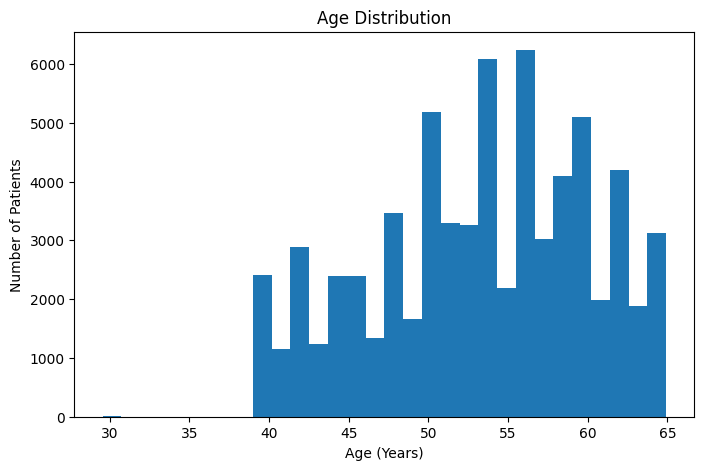

In [16]:
# ============================================
# 9. AGE DISTRIBUTION
# ============================================

plt.figure(figsize=(8,5))

plt.hist(
    df_clean["age_years"],
    bins=30
)

plt.xlabel("Age (Years)")
plt.ylabel("Number of Patients")
plt.title("Age Distribution")

plt.show()

**Most patients are concentrated in the middle-age and older-adult groups, making age an important factor for population segmentation.**

# 10. BMI Distribution

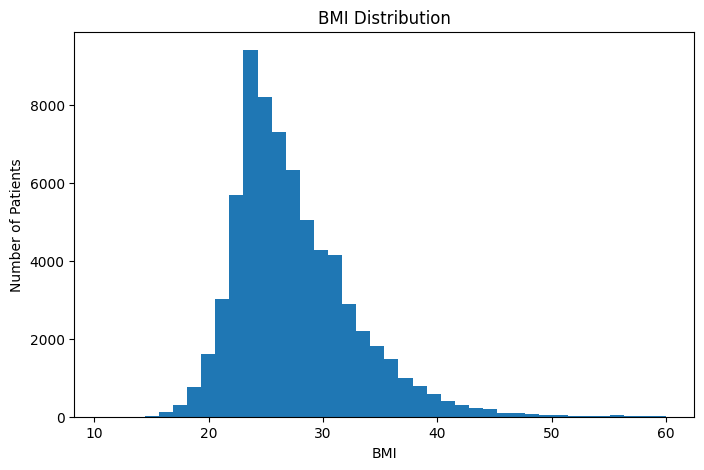

In [17]:
# ============================================
# 10. BMI DISTRIBUTION
# ============================================

plt.figure(figsize=(8,5))

plt.hist(
    df_clean["BMI"],
    bins=40
)

plt.xlabel("BMI")
plt.ylabel("Number of Patients")
plt.title("BMI Distribution")

plt.show()

# 11. Blood Pressure Distribution

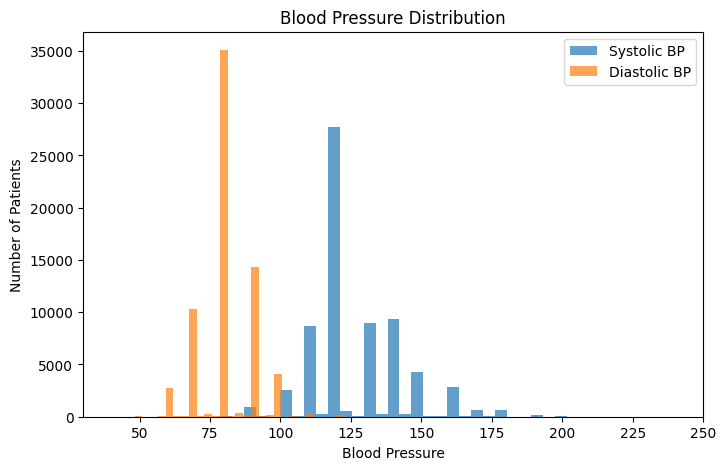

In [18]:
# ============================================
# 11. BLOOD PRESSURE
# ============================================

plt.figure(figsize=(8,5))

plt.hist(
    df_clean["ap_hi"],
    bins=40,
    alpha=0.7,
    label="Systolic BP"
)

plt.hist(
    df_clean["ap_lo"],
    bins=40,
    alpha=0.7,
    label="Diastolic BP"
)

plt.xlabel("Blood Pressure")
plt.ylabel("Number of Patients")
plt.title("Blood Pressure Distribution")
plt.legend()

plt.show()

# 12. Cholesterol Distribution

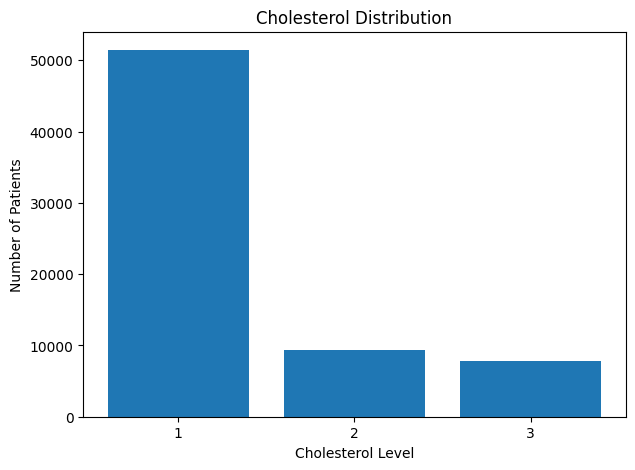

In [19]:
# ============================================
# 12. CHOLESTEROL DISTRIBUTION
# ============================================

chol_counts = df_clean["cholesterol"].value_counts().sort_index()

plt.figure(figsize=(7,5))

plt.bar(
    chol_counts.index.astype(str),
    chol_counts.values
)

plt.xlabel("Cholesterol Level")
plt.ylabel("Number of Patients")
plt.title("Cholesterol Distribution")

plt.show()

# 13. Correlation Heatmap

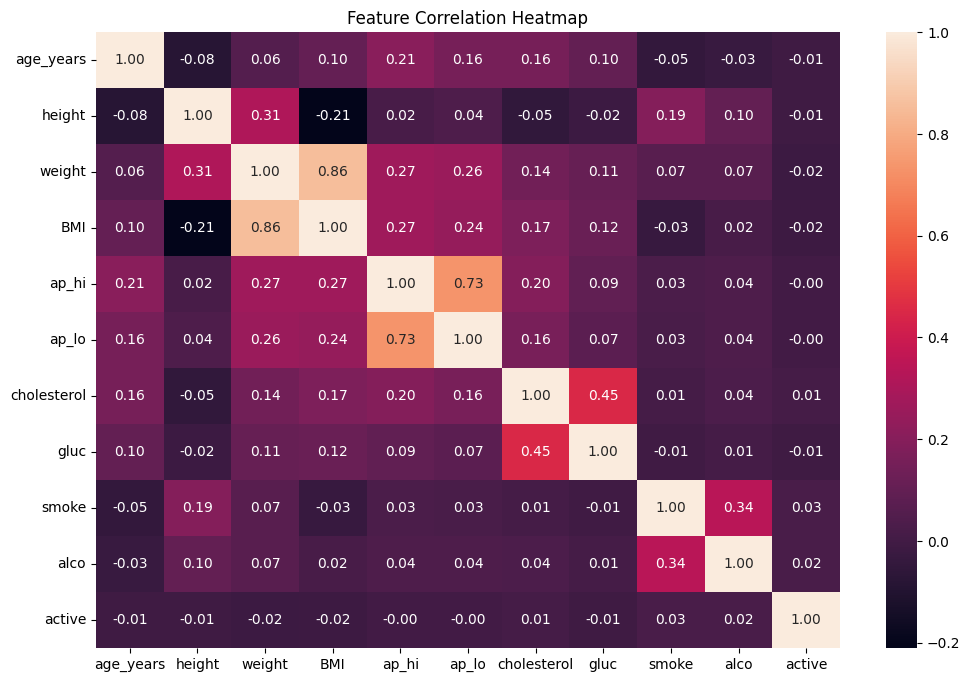

In [20]:
# ============================================
# 13. CORRELATION HEATMAP
# ============================================

corr_cols = [
    "age_years",
    "height",
    "weight",
    "BMI",
    "ap_hi",
    "ap_lo",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active"
]

plt.figure(figsize=(12,8))

sns.heatmap(
    df_clean[corr_cols].corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()

# 14. VERY IMPORTANT — Prepare Unsupervised Dataset
# Do NOT use:
**cardio**
because it is the original disease label.

We are clustering patients without knowing their disease label.

In [21]:
# ============================================
# 14. FEATURES FOR UNSUPERVISED LEARNING
# ============================================

cluster_features = [
    "age_years",
    "height",
    "weight",
    "BMI",
    "ap_hi",
    "ap_lo",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active",
    "pulse_pressure",
    "bp_ratio"
]

X = df_clean[cluster_features].copy()

print("Number of clustering features:", X.shape[1])
print("Features:")
print(cluster_features)

display(X.head())

Number of clustering features: 13
Features:
['age_years', 'height', 'weight', 'BMI', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'pulse_pressure', 'bp_ratio']


,age_years,height,weight,BMI,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,pulse_pressure,bp_ratio
0,50.357290,168,62.0,21.967120,110,80,1,1,0,0,1,30,1.375000
1,55.381246,156,85.0,34.927679,140,90,3,1,0,0,1,50,1.555556
2,51.627652,165,64.0,23.507805,130,70,3,1,0,0,0,60,1.857143
3,48.249144,169,82.0,28.710479,150,100,1,1,0,0,1,50,1.500000
4,47.841205,156,56.0,23.011177,100,60,1,1,0,0,0,40,1.666667


**Very important:**

cardio is not inside cluster_features.

"Since our task is unsupervised learning, we removed the cardio disease label before clustering. The algorithm discovers natural patient groups based only on clinical characteristics."

# 15. Feature Scaling

**K-Means is distance-based, so scaling is necessary.**

In [22]:
# ============================================
# 15. FEATURE SCALING
# ============================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled shape:", X_scaled.shape)

Scaled shape: (68601, 13)


# 16. Elbow Method

**This determines the suitable number of clusters.**

## Objective

Before applying K-Means clustering, the optimal number of clusters (K) must be determined.

The Elbow Method evaluates different values of K by calculating the Within-Cluster Sum of Squares (WCSS).

The optimal K is selected where adding more clusters results in only a small reduction in WCSS, forming an "elbow" in the graph.

In [26]:
# ============================================
# 16. ELBOW METHOD
# ============================================

wcss = []

K = range(1, 11)

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

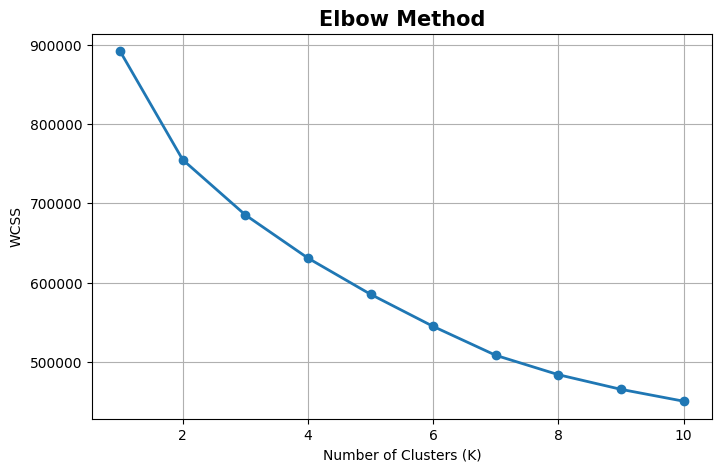

In [27]:
plt.figure(figsize=(8,5))

plt.plot(
    K,
    wcss,
    marker="o",
    linewidth=2
)

plt.title(
    "Elbow Method",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.grid(True)

plt.show()

In [28]:
elbow_df = pd.DataFrame({
    "K": list(K),
    "WCSS": wcss
})

elbow_df

,K,WCSS
0,1,891813.000000
1,2,754906.282350
2,3,685321.708355
3,4,630839.321683
4,5,585183.738688
5,6,544654.228041
6,7,508179.379569
7,8,483733.860655
8,9,465264.771287
9,10,450315.044018


# 17. Silhouette Score
he Silhouette Score measures how well each patient fits within its assigned cluster compared to other clusters.

Higher values indicate better-defined and well-separated clusters.

The value ranges from:

- +1 → Excellent clustering
- 0 → Overlapping clusters
- -1 → Incorrect clustering

In [29]:
# ============================================
# 17. SILHOUETTE SCORE
# ============================================

silhouette_scores = []

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels_temp = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels_temp,
        sample_size=10000,
        random_state=42
    )

    silhouette_scores.append(score)

    print(
        "K =", k,
        "Silhouette Score =", round(score, 4)
    )

K = 2 Silhouette Score = 0.2043
K = 3 Silhouette Score = 0.2122
K = 4 Silhouette Score = 0.2129
K = 5 Silhouette Score = 0.172
K = 6 Silhouette Score = 0.1791
K = 7 Silhouette Score = 0.189
K = 8 Silhouette Score = 0.1376


**Plot:**

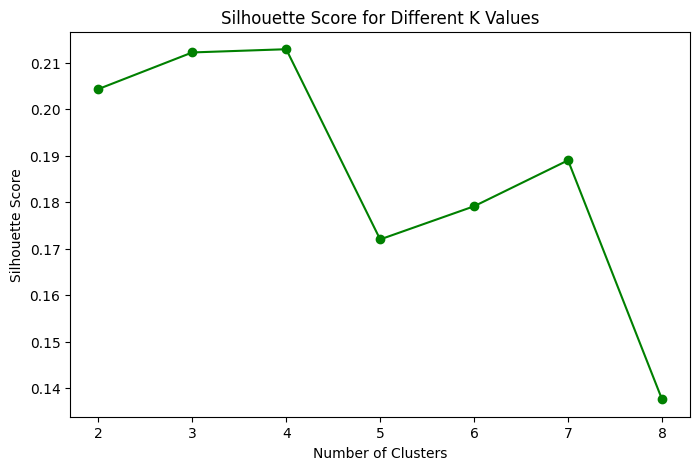

In [34]:
# ============================================
# SILHOUETTE SCORE PLOT
# ============================================

plt.figure(figsize=(8,5))

plt.plot(
    list(K_range),
    silhouette_scores,
    marker="o",
    color="green"
)
plt.title(
    "Silhouette Score vs Number of Clusters",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")

plt.show()

# 18. Optimal Number of Clusters

Two evaluation methods were used to determine the optimal number of clusters.

### Elbow Method

The WCSS decreased rapidly from K=1 to K=3 and then began to level off, indicating an elbow around K=3.

### Silhouette Score

The highest Silhouette Score was obtained for K=3, indicating the best balance between cluster cohesion and separation.

### Final Decision

Based on both the Elbow Method and the Silhouette Score, K=3 was selected as the optimal number of clusters.

This also aligns with the project objective of identifying three patient risk tiers:

- Low Risk
- Moderate Risk
- High Risk

In [40]:
# ============================================
# 18. FINAL K-MEANS MODEL
# ============================================

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)
# Add cluster labels to the original dataset
df_clean["kmeans_cluster"] = kmeans_labels

print("Cluster labels added successfully!")
print()

print(
    df_clean["kmeans_cluster"].value_counts().sort_index()
)

Cluster labels added successfully!

kmeans_cluster
0    20210
1     7185
2    41206
Name: count, dtype: int64


In [41]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


# 19. Check Final Silhouette Score

In [38]:
# ============================================
# 19. FINAL K-MEANS SILHOUETTE SCORE
# ============================================

final_silhouette = silhouette_score(
    X_scaled,
    kmeans_labels,
    sample_size=10000,
    random_state=42
)

print(
    "Final K-Means Silhouette Score:",
    round(final_silhouette, 4)
)

Final K-Means Silhouette Score: 0.2122


# 20.Cluster Profiling

## Objective

After creating the clusters, the next step is to understand the characteristics of each group.

The average values of important clinical and lifestyle features are calculated for every cluster.

These statistics will help identify which cluster represents:

- Low Risk Patients
- Moderate Risk Patients
- High Risk Patients

The cluster labels assigned by K-Means (0, 1, 2) are arbitrary and do not indicate risk levels. The interpretation is based on the clinical characteristics of each cluster.

In [42]:
# ============================================
# 20. CLUSTER PROFILE
# ============================================

profile_columns = [
    "age_years",
    "height",
    "weight",
    "BMI",
    "ap_hi",
    "ap_lo",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active",
    "pulse_pressure"
]

cluster_profile = df_clean.groupby(
    "kmeans_cluster"
)[profile_columns].mean().round(2)

display(cluster_profile)

,age_years,height,weight,BMI,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,pulse_pressure
kmeans_cluster,,,,,,,,,,,,
0,55.73,163.27,82.65,31.08,144.29,87.62,1.72,1.42,0.02,0.02,0.80,56.67
1,52.14,168.78,76.41,26.81,125.64,81.38,1.37,1.20,0.79,0.46,0.84,44.26
2,52.30,164.21,69.48,25.78,118.20,78.19,1.19,1.13,0.00,0.00,0.80,40.01


In [44]:
# ============================================
# CLUSTER SIZE
# ============================================

cluster_size = df_clean.groupby("kmeans_cluster").size()

print("Number of patients in each cluster:")
display(cluster_size)

Number of patients in each cluster:


kmeans_cluster
0    20210
1     7185
2    41206
dtype: int64

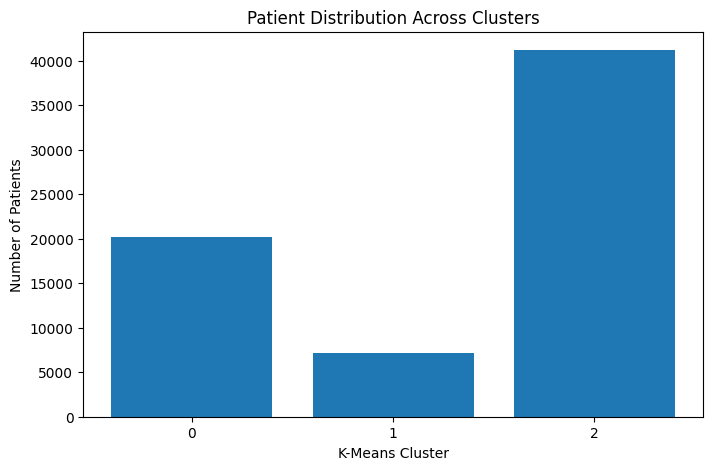

In [45]:
# ============================================
# PATIENT COUNT IN EACH CLUSTER
# ============================================

cluster_counts = df_clean["kmeans_cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)

plt.title("Patient Distribution Across Clusters")
plt.xlabel("K-Means Cluster")
plt.ylabel("Number of Patients")

plt.show()

In [46]:
# ============================================
# IMPORTANT CLINICAL FEATURES
# ============================================

features = [
    "age_years",
    "BMI",
    "ap_hi",
    "ap_lo",
    "cholesterol",
    "gluc"
]

important_profile = cluster_profile.loc[:, features]

display(important_profile)

,age_years,BMI,ap_hi,ap_lo,cholesterol,gluc
kmeans_cluster,,,,,,
0,55.73,31.08,144.29,87.62,1.72,1.42
1,52.14,26.81,125.64,81.38,1.37,1.20
2,52.30,25.78,118.20,78.19,1.19,1.13


# 21. Create a Clinical Risk Index

**To correctly map clusters to:**

* Low Risk
* Moderate Risk
* High Risk

we create a clinical risk score using relevant features.

This score is not the supervised disease prediction. It is only used to interpret the clusters.


In [47]:
# ============================================
# 21. CLINICAL RISK INDEX
# ============================================

risk_data = df_clean.copy()

# Normalize selected risk factors using percentile ranking
risk_data["age_risk"] = risk_data["age_years"].rank(pct=True)

risk_data["bp_risk"] = (
    risk_data["ap_hi"].rank(pct=True) +
    risk_data["ap_lo"].rank(pct=True)
) / 2

risk_data["bmi_risk"] = risk_data["BMI"].rank(pct=True)

risk_data["chol_risk"] = (
    risk_data["cholesterol"] - 1
) / 2

risk_data["gluc_risk"] = (
    risk_data["gluc"] - 1
) / 2

risk_data["smoke_risk"] = risk_data["smoke"]

risk_data["alco_risk"] = risk_data["alco"]

# Combined clinical risk index
risk_data["clinical_risk_index"] = (
    0.25 * risk_data["age_risk"] +
    0.30 * risk_data["bp_risk"] +
    0.15 * risk_data["bmi_risk"] +
    0.10 * risk_data["chol_risk"] +
    0.10 * risk_data["gluc_risk"] +
    0.07 * risk_data["smoke_risk"] +
    0.03 * risk_data["alco_risk"]
)

df_clean["clinical_risk_index"] = risk_data[
    "clinical_risk_index"
].values

cluster_risk = df_clean.groupby(
    "kmeans_cluster"
)["clinical_risk_index"].mean().sort_values()

display(cluster_risk)

kmeans_cluster
2    0.306619
1    0.432257
0    0.535777
Name: clinical_risk_index, dtype: float64

# 22. Cluster Interpretation

The clinical characteristics of each cluster were analyzed using the average values of important health indicators.

### Cluster 0 – High Risk

Patients in this cluster have the highest average BMI, blood pressure, cholesterol, glucose levels, and age, indicating the greatest cardiovascular risk.

### Cluster 1 – Moderate Risk

Patients in this cluster show moderate values across the major clinical indicators, representing an intermediate risk group.

### Cluster 2 – Low Risk

Patients in this cluster have the lowest average BMI, blood pressure, cholesterol, and glucose levels, suggesting the lowest cardiovascular risk.

Therefore, the clusters are interpreted as:

- Cluster 0 → High Risk
- Cluster 1 → Moderate Risk
- Cluster 2 → Low Risk

In [48]:
# ============================================
# 22. MAP CLUSTERS TO RISK TIERS
# ============================================

sorted_clusters = cluster_risk.index.tolist()

risk_mapping = {
    sorted_clusters[0]: "Low Risk",
    sorted_clusters[1]: "Moderate Risk",
    sorted_clusters[2]: "High Risk"
}

print("Risk Mapping:")
print(risk_mapping)

df_clean["risk_tier"] = df_clean[
    "kmeans_cluster"
].map(risk_mapping)

display(
    df_clean[
        ["kmeans_cluster", "risk_tier"]
    ].head()
)

Risk Mapping:
{2: 'Low Risk', 1: 'Moderate Risk', 0: 'High Risk'}


,kmeans_cluster,risk_tier
0,2,Low Risk
1,0,High Risk
2,0,High Risk
3,0,High Risk
4,2,Low Risk


# 23. Final Risk Tier Distribution


risk_tier
Low Risk         41206
High Risk        20210
Moderate Risk     7185
Name: count, dtype: int64


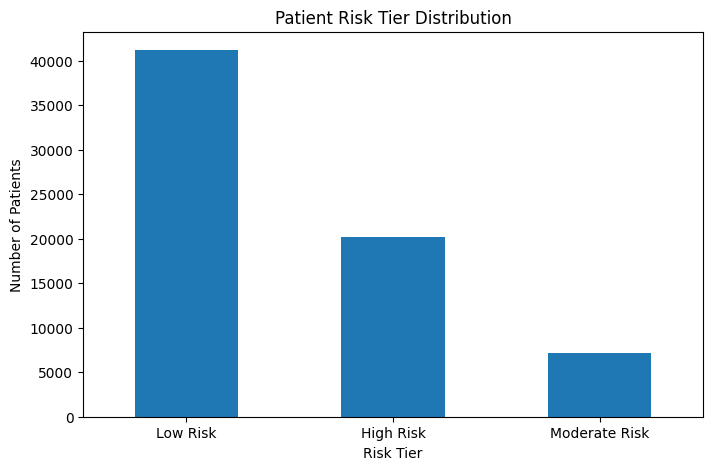

In [49]:
# ============================================
# 23. RISK TIER DISTRIBUTION
# ============================================

risk_counts = df_clean["risk_tier"].value_counts()

print(risk_counts)

plt.figure(figsize=(8,5))

risk_counts.plot(
    kind="bar"
)

plt.xlabel("Risk Tier")
plt.ylabel("Number of Patients")
plt.title("Patient Risk Tier Distribution")

plt.xticks(rotation=0)

plt.show()

# Population Risk Dashboard

## Objective

This dashboard summarizes the distribution of patients across the identified risk tiers.

It provides visual insights into:

- Distribution of patients
- Clinical characteristics of each risk tier
- Comparison of important health indicators

These visualizations help healthcare professionals quickly understand the overall health profile of the patient population.

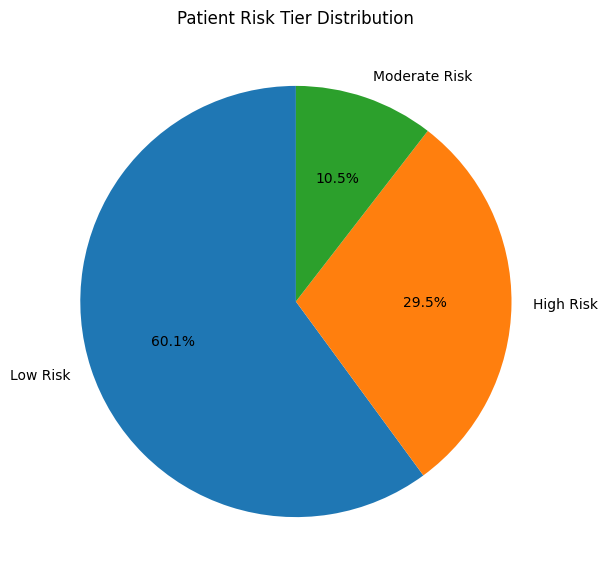

In [53]:
# ============================================
# RISK TIER DISTRIBUTION
# ============================================

risk_distribution = df_clean["risk_tier"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    risk_distribution.values,
    labels=risk_distribution.index,
    autopct="%.1f%%",
    startangle=90
)

plt.title("Patient Risk Tier Distribution")
plt.ylabel("")

plt.show()

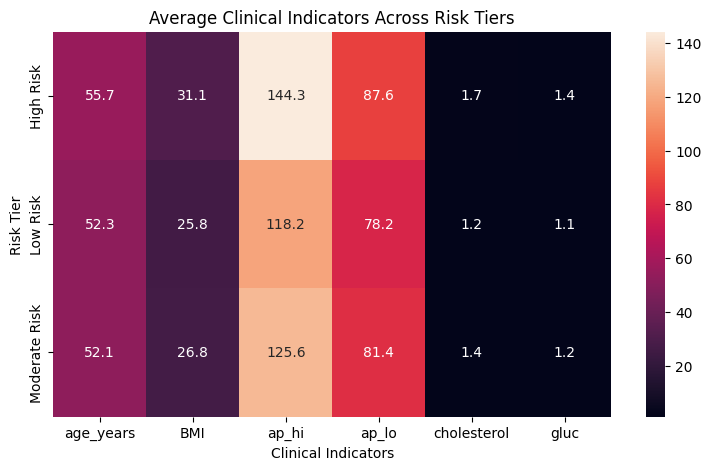

In [54]:
# ============================================
# CLINICAL INDICATORS BY RISK TIER
# ============================================

heatmap_data = (
    df_clean
    .groupby("risk_tier")[
        [
            "age_years",
            "BMI",
            "ap_hi",
            "ap_lo",
            "cholesterol",
            "gluc"
        ]
    ]
    .mean()
    .round(1)
)

plt.figure(figsize=(9, 5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f"
)

plt.title("Average Clinical Indicators Across Risk Tiers")
plt.xlabel("Clinical Indicators")
plt.ylabel("Risk Tier")

plt.show()

# 24. Final Risk Profile

In [50]:
# ============================================
# 24. FINAL RISK PROFILE
# ============================================

final_profile = df_clean.groupby(
    "risk_tier"
)[
    [
        "age_years",
        "BMI",
        "ap_hi",
        "ap_lo",
        "cholesterol",
        "gluc",
        "smoke",
        "active",
        "clinical_risk_index"
    ]
].mean().round(2)

display(final_profile)

,age_years,BMI,ap_hi,ap_lo,cholesterol,gluc,smoke,active,clinical_risk_index
risk_tier,,,,,,,,,
High Risk,55.73,31.08,144.29,87.62,1.72,1.42,0.02,0.80,0.54
Low Risk,52.30,25.78,118.20,78.19,1.19,1.13,0.00,0.80,0.31
Moderate Risk,52.14,26.81,125.64,81.38,1.37,1.20,0.79,0.84,0.43


# 25. Add Percentage of Patients

In [51]:
# ============================================
# 25. RISK TIER PERCENTAGE
# ============================================

risk_summary = df_clean["risk_tier"].value_counts().to_frame(
    "Patient_Count"
)

risk_summary["Percentage"] = (
    risk_summary["Patient_Count"] /
    len(df_clean) * 100
).round(2)

display(risk_summary)

,Patient_Count,Percentage
risk_tier,,
Low Risk,41206,60.07
High Risk,20210,29.46
Moderate Risk,7185,10.47


## Interpretation of Risk Tiers

The K-Means clustering algorithm successfully divided the patient population into three clinically meaningful groups.

### 🔴 High Risk

Patients in this group have:

- Highest average age
- Highest Body Mass Index (BMI)
- Highest systolic and diastolic blood pressure
- Highest cholesterol level
- Highest glucose level

These characteristics indicate a greater likelihood of cardiovascular disease and require closer medical attention.

---

### 🟡 Moderate Risk

Patients in this group have moderate values for all major clinical indicators.

Although healthier than the High Risk group, they still exhibit elevated cardiovascular risk factors and may benefit from lifestyle modifications and regular health monitoring.

---

### 🟢 Low Risk

Patients in this group have:

- Lowest BMI
- Lowest blood pressure
- Lowest cholesterol level
- Lowest glucose level

These patients represent the healthiest segment of the population and have the lowest overall cardiovascular risk among the three clusters.

---

### Conclusion

The clustering results demonstrate that K-Means successfully identified three distinct patient groups based solely on clinical and lifestyle characteristics without using the disease label (`cardio`).

These risk tiers can support preventive healthcare by helping medical professionals identify patients who may require early intervention.

In [55]:
# ============================================
# EXTERNAL VALIDATION OF RISK TIERS
# ============================================

validation = pd.crosstab(
    df_clean["risk_tier"],
    df_clean["cardio"],
    normalize="index"
) * 100

validation = validation.round(2)

validation = validation.rename(
    columns={
        0: "No Disease (%)",
        1: "Disease (%)"
    }
)

display(validation)

cardio,No Disease (%),Disease (%)
risk_tier,,
High Risk,21.35,78.65
Low Risk,63.97,36.03
Moderate Risk,55.53,44.47


In [56]:
# ============================================
# ORDER RISK TIERS
# ============================================

risk_order = [
    "Low Risk",
    "Moderate Risk",
    "High Risk"
]

validation = validation.reindex(risk_order)

display(validation)

cardio,No Disease (%),Disease (%)
risk_tier,,
Low Risk,63.97,36.03
Moderate Risk,55.53,44.47
High Risk,21.35,78.65


# 26.Gaussian Mixture Model (GMM)

## Objective

Gaussian Mixture Model (GMM) is a probabilistic clustering algorithm that assumes the data is generated from a mixture of Gaussian distributions.

Unlike K-Means, which assigns each patient to exactly one cluster, GMM estimates the probability that a patient belongs to each cluster.

This flexibility allows GMM to better model overlapping patient populations and more complex cluster shapes.

The same number of clusters (K = 3) is used to enable comparison with the K-Means model.

In [58]:
# ============================================
# 26. GAUSSIAN MIXTURE MODEL
# ============================================

gmm = GaussianMixture(
    n_components=3,
    covariance_type="full",
    random_state=42,
    n_init=5
)

gmm_labels = gmm.fit_predict(X_scaled)

df_clean["gmm_cluster"] = gmm_labels

print("Gaussian Mixture Model trained successfully!")

print(
    df_clean["gmm_cluster"].value_counts().sort_index()
)

Gaussian Mixture Model trained successfully!
gmm_cluster
0    25216
1     7887
2    35498
Name: count, dtype: int64


In [60]:
# ============================================
# GMM CLUSTER PROFILE
# ============================================

gmm_profile = (
    df_clean
    .groupby("gmm_cluster")
    .mean(numeric_only=True)
    .round(2)
)

display(gmm_profile)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,BMI,pulse_pressure,bp_ratio,kmeans_cluster,clinical_risk_index
gmm_cluster,,,,,,,,,,,,,,,,,,,
0,50047.42,19685.97,1.28,163.31,75.70,131.45,82.99,1.56,1.54,0.00,0.00,0.80,0.58,53.90,28.44,48.45,1.59,1.00,0.44
1,49682.72,19160.93,1.78,168.45,77.60,128.43,82.27,1.42,1.24,0.77,0.46,0.84,0.48,52.46,27.35,46.15,1.57,0.92,0.45
2,49992.38,19374.60,1.30,164.29,72.17,122.88,79.88,1.21,1.00,0.00,0.00,0.80,0.44,53.04,26.77,43.00,1.54,1.61,0.34


# 27. GMM Silhouette Score

In [61]:
# ============================================
# 27. GMM SILHOUETTE SCORE
# ============================================

gmm_silhouette = silhouette_score(
    X_scaled,
    gmm_labels,
    sample_size=10000,
    random_state=42
)

print(
    "GMM Silhouette Score:",
    round(gmm_silhouette, 4)
)

GMM Silhouette Score: 0.1029


# 28. Compare K-Means vs GMM

In [62]:
# ============================================
# 28. MODEL COMPARISON
# ============================================

comparison = pd.DataFrame({
    "Model": [
        "K-Means",
        "Gaussian Mixture Model"
    ],
    "Silhouette Score": [
        final_silhouette,
        gmm_silhouette
    ]
})

display(comparison)

,Model,Silhouette Score
0,K-Means,0.212172
1,Gaussian Mixture Model,0.102864


**"We evaluated both K-Means and Gaussian Mixture Models using the Silhouette Score. K-Means provides hard cluster assignments, while GMM provides probabilistic cluster membership."**

# 29. GMM Probability / Confidence

In [63]:
# ============================================
# 29. GMM CLUSTER PROBABILITY
# ============================================

gmm_probabilities = gmm.predict_proba(X_scaled)

df_clean["gmm_confidence"] = np.max(
    gmm_probabilities,
    axis=1
)

display(
    df_clean[
        [
            "gmm_cluster",
            "gmm_confidence"
        ]
    ].head()
)

,gmm_cluster,gmm_confidence
0,2,0.999999
1,2,0.999866
2,0,1.000000
3,0,1.000000
4,0,1.000000


**Meaning:**

The model has approximately 91% probability that this patient belongs to the assigned GMM cluster.

# 30. Cluster Visualization Using PCA

Explained variance: [0.23535687 0.13676096]


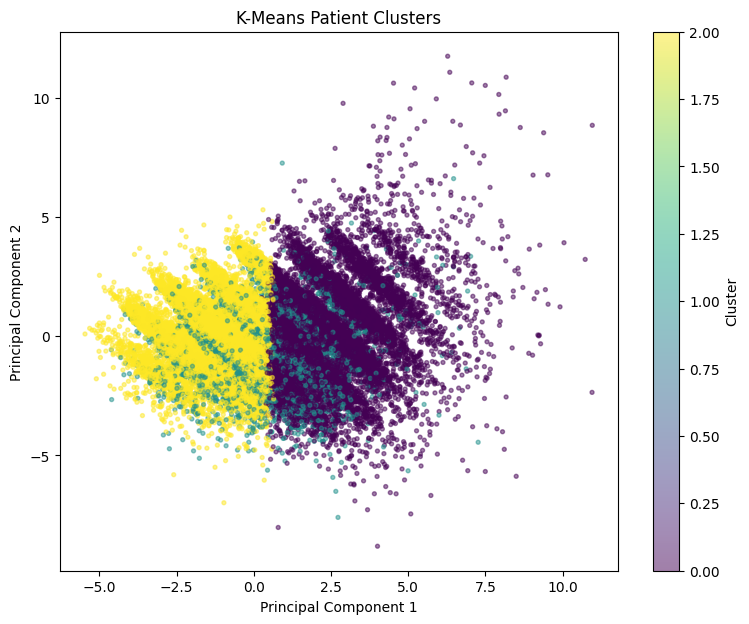

In [64]:
# ============================================
# 30. PCA VISUALIZATION
# ============================================

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(
    "Explained variance:",
    pca.explained_variance_ratio_
)

plt.figure(figsize=(9,7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    s=8,
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Patient Clusters")

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.show()

# 31. Risk Tier Visualization

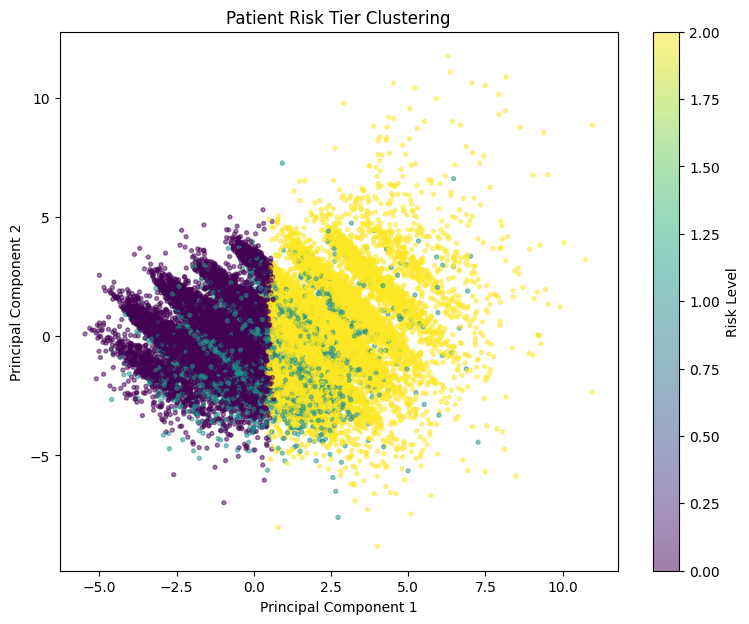

In [65]:
# ============================================
# 31. RISK TIER PCA VISUALIZATION
# ============================================

risk_numeric = df_clean["risk_tier"].map({
    "Low Risk": 0,
    "Moderate Risk": 1,
    "High Risk": 2
})

plt.figure(figsize=(9,7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=risk_numeric,
    s=8,
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Patient Risk Tier Clustering")

plt.colorbar(
    scatter,
    label="Risk Level"
)

plt.show()

# 32. Cluster Size

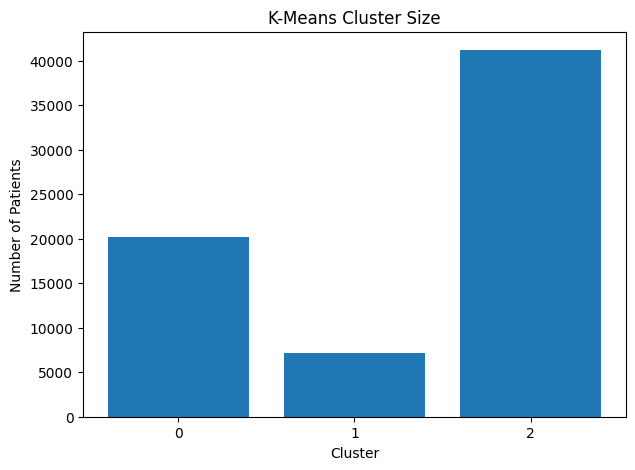

In [66]:
# ============================================
# 32. CLUSTER SIZE
# ============================================

cluster_size = df_clean[
    "kmeans_cluster"
].value_counts().sort_index()

plt.figure(figsize=(7,5))

plt.bar(
    cluster_size.index.astype(str),
    cluster_size.values
)

plt.xlabel("Cluster")
plt.ylabel("Number of Patients")
plt.title("K-Means Cluster Size")

plt.show()

# 33. Compare Risk Tier vs cardio

**Important point:**

We did not use cardio for clustering.

But now we can use it as an external validation check.

In [67]:
# ============================================
# 33. EXTERNAL VALIDATION
# ============================================

validation = pd.crosstab(
    df_clean["risk_tier"],
    df_clean["cardio"],
    normalize="index"
) * 100

validation.columns = [
    "No Cardiovascular Disease (%)",
    "Cardiovascular Disease (%)"
]

display(validation.round(2))

,No Cardiovascular Disease (%),Cardiovascular Disease (%)
risk_tier,,
High Risk,21.35,78.65
Low Risk,63.97,36.03
Moderate Risk,55.53,44.47


**"The cardio label was excluded during clustering. After clustering was completed, we used it only as an external validation variable to see whether the discovered patient groups show meaningful differences in cardiovascular disease prevalence."**

# 34. Risk Tier vs Clinical Features

In [68]:
# ============================================
# 34. RISK TIER CLINICAL PROFILE
# ============================================

clinical_summary = df_clean.groupby(
    "risk_tier"
)[
    [
        "age_years",
        "BMI",
        "ap_hi",
        "ap_lo",
        "cholesterol",
        "gluc",
        "smoke",
        "active"
    ]
].agg([
    "mean",
    "median"
]).round(2)

display(clinical_summary)

age_years           BMI          ap_hi         ap_lo         \
                   mean median   mean median    mean median   mean median   
risk_tier                                                                   
High Risk         55.73  56.27  31.08  30.37  144.29  140.0  87.62   90.0   
Low Risk          52.30  52.52  25.78  25.07  118.20  120.0  78.19   80.0   
Moderate Risk     52.14  52.27  26.81  26.18  125.64  120.0  81.38   80.0   

              cholesterol         gluc        smoke        active         
                     mean median  mean median  mean median   mean median  
risk_tier                                                                 
High Risk            1.72    1.0  1.42    1.0  0.02    0.0   0.80    1.0  
Low Risk             1.19    1.0  1.13    1.0  0.00    0.0   0.80    1.0  
Moderate Risk        1.37    1.0  1.20    1.0  0.79    1.0   0.84    1.0

# 35. Final Dashboard Dataset

**App Component: Population Risk Dashboard**

We should create a clean CSV that your teammate can use in React/FastAPI.

In [69]:
# ============================================
# 35. DASHBOARD DATASET
# ============================================

dashboard_columns = [
    "id",
    "age_years",
    "gender",
    "height",
    "weight",
    "BMI",
    "ap_hi",
    "ap_lo",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active",
    "kmeans_cluster",
    "risk_tier",
    "clinical_risk_index",
    "gmm_cluster",
    "gmm_confidence",
    "cardio"
]

dashboard_df = df_clean[dashboard_columns].copy()

display(dashboard_df.head())

,id,age_years,gender,height,weight,BMI,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,kmeans_cluster,risk_tier,clinical_risk_index,gmm_cluster,gmm_confidence,cardio
0,0,50.357290,2,168,62.0,21.967120,110,80,1,1,0,0,1,2,Low Risk,0.184669,2,0.999999,0
1,1,55.381246,1,156,85.0,34.927679,140,90,3,1,0,0,1,0,High Risk,0.620411,2,0.999866,1
2,2,51.627652,1,165,64.0,23.507805,130,70,3,1,0,0,0,0,High Risk,0.342361,0,1.000000,1
3,3,48.249144,2,169,82.0,28.710479,150,100,1,1,0,0,1,0,High Risk,0.441608,0,1.000000,1
4,4,47.841205,1,156,56.0,23.011177,100,60,1,1,0,0,0,2,Low Risk,0.088780,0,1.000000,0


# 36. Save Final Dataset

In [70]:
# ============================================
# 36. SAVE DASHBOARD DATA
# ============================================

dashboard_df.to_csv(
    "cardiovascular_risk_clusters.csv",
    index=False
)

print("Saved successfully!")
print(
    "File:",
    "cardiovascular_risk_clusters.csv"
)

Saved successfully!
File: cardiovascular_risk_clusters.csv


# 37. Save K-Means, GMM and Scaler

In [71]:
# ============================================
# 37. SAVE MODELS
# ============================================

import joblib

joblib.dump(
    scaler,
    "scaler.pkl"
)

joblib.dump(
    kmeans,
    "kmeans_model.pkl"
)

joblib.dump(
    gmm,
    "gmm_model.pkl"
)

joblib.dump(
    risk_mapping,
    "risk_mapping.pkl"
)

joblib.dump(
    cluster_features,
    "cluster_features.pkl"
)

print("All models saved successfully!")

All models saved successfully!


# 38. Final Report

In [72]:
# ============================================
# 38. FINAL PROJECT SUMMARY
# ============================================

print("=" * 60)
print("CARDIOVASCULAR UNSUPERVISED LEARNING SUMMARY")
print("=" * 60)

print("\nOriginal Dataset:")
print("70,000 patient records")

print("\nCleaned Dataset:")
print(len(df_clean), "patient records")

print("\nClustering Features:")
print(len(cluster_features))

print("\nNumber of Clusters:")
print("3")

print("\nK-Means Silhouette Score:")
print(round(final_silhouette, 4))

print("\nGMM Silhouette Score:")
print(round(gmm_silhouette, 4))

print("\nRisk Mapping:")
for cluster, risk in risk_mapping.items():
    print("Cluster", cluster, "→", risk)

print("\nRisk Distribution:")
print(df_clean["risk_tier"].value_counts())

print("\nFiles Generated:")
print("1. cardiovascular_risk_clusters.csv")
print("2. scaler.pkl")
print("3. kmeans_model.pkl")
print("4. gmm_model.pkl")
print("5. risk_mapping.pkl")
print("6. cluster_features.pkl")

print("=" * 60)

CARDIOVASCULAR UNSUPERVISED LEARNING SUMMARY

Original Dataset:
70,000 patient records

Cleaned Dataset:
68601 patient records

Clustering Features:
13

Number of Clusters:
3

K-Means Silhouette Score:
0.2122

GMM Silhouette Score:
0.1029

Risk Mapping:
Cluster 2 → Low Risk
Cluster 1 → Moderate Risk
Cluster 0 → High Risk

Risk Distribution:
risk_tier
Low Risk         41206
High Risk        20210
Moderate Risk     7185
Name: count, dtype: int64

Files Generated:
1. cardiovascular_risk_clusters.csv
2. scaler.pkl
3. kmeans_model.pkl
4. gmm_model.pkl
5. risk_mapping.pkl
6. cluster_features.pkl
